# NLP Supervisé (FR) — Classification d’émotions

Ce TP utilise un **corpus synthétique de 500 phrases** étiquetées sur 5 émotions (`joie`, `colère`, `peur`, `tristesse`, `surprise`),
puis entraîne et évalue des modèles supervisés (TF‑IDF + **LogisticRegression** et **LinearSVC**).

## Plan
1. Exploration & visualisation
2. Prétraitement (normalisation, accents, stopwords)
3. Vectorisation TF‑IDF
4. Modèles (LogisticRegression, LinearSVC)
5. Évaluation (accuracy, macro‑F1, rapport par classe, matrice de confusion)
6. Sauvegarde du meilleur modèle + tests manuels

> **Astuce** : ce corpus est synthétique et équilibré pour fins pédagogiques ; sur un corpus réel, pensez à gérer le déséquilibre, le bruit, et à itérer sur les features.


## 0) Installation & imports
- Nous utilisons `scikit-learn`, `pandas`, `matplotlib`.
- Aucun accès Internet nécessaire ; le prétraitement repose sur une petite liste de stopwords intégrée au notebook.

In [3]:
# !pip install -q numpy pandas scikit-learn matplotlib joblib
import random
import re
import string
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1) Exploration & visualisation
Regardons la distribution des classes et un aperçu des premières lignes.

In [4]:
import pandas as pd
corpus_emotions_fr_500 = pd.read_csv('corpus_emotions_fr_500.csv', sep = ',')
df = corpus_emotions_fr_500

In [5]:
df

,texte,emotion
0,Je redoute ce qui va arriver !,peur
1,J'ai si peur !! 😱,peur
2,Je suis particulièrement en colère 🤬,colère
3,Je traverse une période difficile . 😢,tristesse
4,Je redoute ce qui va arriver !!,peur
...,...,...
495,Je ne supporte plus la météo !!,colère
496,Cette le match m'inquiète .,peur
497,C'est un jour morose !!,tristesse
498,Je suis très heureux aujourd'hui 🥳,joie


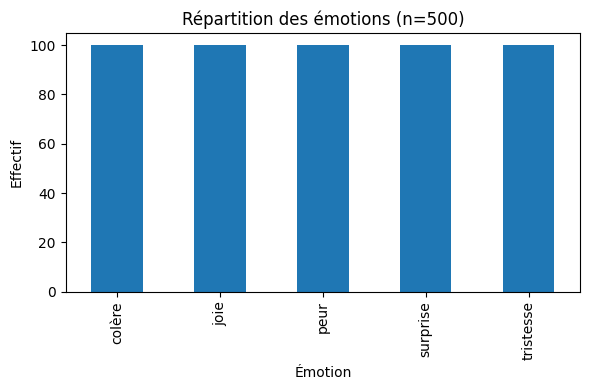

In [6]:
counts = df["emotion"].value_counts().sort_index()
plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Répartition des émotions (n=500)")
plt.xlabel("Émotion")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

## 2) Prétraitement
Prétraitement léger sans dépendances externes :
- Mise en minuscules
- Suppression d’URLs/emails
- Normalisation des accents
- Suppression de la ponctuation
- Tokenisation regex + **stopwords** FR intégrés

Nous intégrerons `clean_text` directement dans le `TfidfVectorizer(preprocessor=...)` pour garantir que la vectorisation se fasse sur du texte propre.

In [7]:
FRENCH_STOPWORDS = {
    "alors","au","aucuns","aussi","autre","avant","avec","avoir","bon","car","ce","cela",
    "ces","ceux","chaque","ci","comme","comment","dans","des","du","dedans","dehors",
    "depuis","devrait","doit","donc","dos","droite","début","elle","elles","en","encore",
    "essai","est","et","eu","fait","faites","fois","font","force","haut","hors","ici",
    "il","ils","je","juste","là","la","le","les","leur","lui","ma","maintenant","mais",
    "mes","mine","moins","mon","mot","même","ni","nommés","notre","nous","nouveaux","ou",
    "où","par","parce","parole","pas","personnes","peu","peut","plupart","pour","pourquoi",
    "quand","que","quel","quelle","quelles","quels","qui","sa","sans","ses","seulement",
    "si","sien","son","sont","sous","soyez","sujet","sur","ta","tandis","tellement","tels",
    "tes","ton","tous","tout","trop","très","tu","valeur","voie","voient","vont","votre",
    "vous","vu","ça","étaient","état","étions","été","être"
}

def strip_accents(text: str) -> str:
    text_nfkd = unicodedata.normalize("NFKD", text)
    return "".join([c for c in text_nfkd if not unicodedata.combining(c)])

def clean_text(text: str) -> str:
    t = text.lower()
    t = re.sub(r"http\S+|www\.\S+|\S+@\S+", " ", t)  # URLs/emails
    t = strip_accents(t)  # accents → ASCII
    t = t.translate(str.maketrans("", "", string.punctuation + "’“”«»—–"))
    tokens = re.findall(r"[a-zàâçéèêëîïôûùüÿñæœ]+", t)
    tokens = [tok for tok in tokens if tok not in FRENCH_STOPWORDS and len(tok) > 1]
    return " ".join(tokens)

# Démonstration rapide
for txt in df["texte"].head(5):
    print(f"RAW: {txt}\nCLEAN: {clean_text(txt)}\n")

RAW: Je redoute ce qui va arriver !
CLEAN: redoute va arriver

RAW: J'ai si peur !! 😱
CLEAN: jai peur

RAW: Je suis particulièrement en colère 🤬
CLEAN: suis particulierement colere

RAW: Je traverse une période difficile . 😢
CLEAN: traverse une periode difficile

RAW: Je redoute ce qui va arriver !!
CLEAN: redoute va arriver



## 3) Split Train/Test (stratifié)
On conserve la proportion des classes via `stratify`.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df["texte"], df["emotion"], test_size=0.2, random_state=RANDOM_STATE, stratify=df["emotion"]
)
len(X_train), len(X_test)

(400, 100)

## 4) Pipelines TF‑IDF + Modèles
- N‑grams (1,2) pour capturer quelques expressions courtes.
- `min_df=2` : ignore les termes trop rares.
- Deux classifieurs : `LogisticRegression` et `LinearSVC`.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(preprocessor=clean_text, ngram_range=(1,2), min_df=2)),
    ("clf", LogisticRegression(max_iter=200))
])

pipe_svc = Pipeline([
    ("tfidf", TfidfVectorizer(preprocessor=clean_text, ngram_range=(1,2), min_df=2)),
    ("clf", LinearSVC())
])

print("Entraînement LogisticRegression…")
pipe_lr.fit(X_train, y_train)
print("Entraînement LinearSVC…")
pipe_svc.fit(X_train, y_train)

Entraînement LogisticRegression…
Entraînement LinearSVC…


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,<function cle...0028792F5D440>
,tokenizer,None


## 5) Évaluation (Accuracy, Macro‑F1, Rapport, Matrice de confusion)
Fonction utilitaire pour comparer les modèles et afficher la matrice de confusion.

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt

def eval_and_report(model, name, emotions_order=None):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.3f} | Macro-F1: {f1m:.3f}")
    print(classification_report(y_test, y_pred, digits=3))
    
    labels = emotions if emotions_order is None else emotions_order
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(5.5,4.5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Matrice de confusion — {name}")
    plt.xlabel("Prédit")
    plt.ylabel("Vrai")
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
    plt.yticks(ticks=range(len(labels)), labels=labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()
    return acc, f1m

acc_lr, f1_lr = eval_and_report(pipe_lr, "TF-IDF + LogisticRegression")
acc_svc, f1_svc = eval_and_report(pipe_svc, "TF-IDF + LinearSVC")


=== TF-IDF + LogisticRegression ===
Accuracy: 1.000 | Macro-F1: 1.000
              precision    recall  f1-score   support

      colère      1.000     1.000     1.000        20
        joie      1.000     1.000     1.000        20
        peur      1.000     1.000     1.000        20
    surprise      1.000     1.000     1.000        20
   tristesse      1.000     1.000     1.000        20

    accuracy                          1.000       100
   macro avg      1.000     1.000     1.000       100
weighted avg      1.000     1.000     1.000       100



NameError: name 'emotions' is not defined

## 6) Sauvegarde du meilleur modèle + tests manuels
On compare les Macro‑F1 et on sauvegarde le meilleur pipeline avec `joblib`.

In [11]:
best_name = "LinearSVC" if f1_svc >= f1_lr else "LogisticRegression"
best_model = pipe_svc if f1_svc >= f1_lr else pipe_lr

model_path = out_dir / f"modele_emotions_fr_tfidf_{best_name}.joblib"
import joblib
joblib.dump(best_model, model_path)
model_path

NameError: name 'f1_svc' is not defined

In [ ]:
tests = [
    "Je suis tellement content de la nouvelle !",
    "Je ne m'y attendais absolument pas...",
    "Cette décision m'énerve profondément !!",
    "J'ai peur de l'entretien demain",
    "Je me sens très triste aujourd'hui",
]
preds = best_model.predict(pd.Series(tests))
list(zip(tests, preds))

## 7) Pistes d’amélioration (à essayer)
- **Comparer BoW vs TF‑IDF** (`CountVectorizer` vs `TfidfVectorizer`).
- **Recherche d’hyperparamètres** (`GridSearchCV`, `RandomizedSearchCV`).
- **Embeddings** (`Word2Vec`, `FastText`) ou **transformers** (BERT multilingue).
- **Explicabilité** : poids TF‑IDF les plus discriminants par classe.
- **Déséquilibre** : `class_weight='balanced'` ou sur‑échantillonnage (SMOTE).
- **Nettoyage plus fin** : lemmatisation (spaCy) et gestion fine des emojis/ponctuation.

> Sur corpus réel, n’oubliez pas la **validation croisée**, la **séparation stricte** (éviter les fuites), et une **évaluation robuste**.
